# Import libraries

In [19]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt

# Load full ground truth

In [20]:
def load_gt(gt_fname):
    with open(gt_fname) as f:
        gt = json.load(f)

    rows_gt = []
    for video_id, info in gt["database"].items():
        duration = info["duration"]
        subset = info["subset"]
        for s in info["annotations"]:
            rows_gt.append(
                {
                    "video_id": video_id,
                    "duration": duration,
                    "subset": subset,
                    "start": s["segment"][0],
                    "end": s["segment"][1],
                    "label": s["label"],
                }
            )

    return pd.DataFrame(rows_gt)

In [21]:
gt_df = load_gt("../data/charades/annotations/charades.json")

# Load EXO_EGO annotations

In [22]:
ego_df = pd.read_csv("../data/charades/annotations/CharadesEgo_v1_train_only1st.csv")
ego_df.head()

,id,subject,scene,quality,relevance,verified,script,objects,descriptions,actions,length,egocentric,charades_video
0,D3TR8EGO,2Q9D,Closet / Walk-in closet / Spear closet,7.0,7.0,Yes,A person walks into the closet and turns on th...,cup/glass/bottle;door;food;glass of water;ligh...,The person in the video walks into a room and ...,c156 3.90 12.00;c061 8.20 12.50;c106 9.90 18.4...,31.79,Yes,1K0SU
1,65JW9EGO,ZG1V,Living room,3.0,7.0,Yes,"A person was walking towards the sofa, and tak...",couch;floor;food;glass;pillow;table;window,A person walks into a room and grabs a pillow ...,c109 19.90 24.29;c107 16.80 23.80;c106 10.10 2...,27.38,Yes,NaN
2,3UML4EGO,0AC0,Home Office / Study (A room in a house used fo...,7.0,7.0,Yes,A person is sitting in a chair in their home o...,chair;coffee;cup;desk;phone;table,person is sitting on a chair playing on the ph...,c107 16.50 22.04;c110 15.30 21.00;c109 23.10 2...,26.75,Yes,NaN
3,6U5TEEGO,5LWB,Bathroom,6.0,6.0,Yes,One person washes a mirror and tidies up while...,blanket;cloth;mirror;sofa/couch;towel,A person cleans mirror and another person take...,c073 14.90 20.00;c095 0.00 15.90;c070 10.20 20...,21.75,Yes,YFZRG
4,KCSBQEGO,UN1T,Living room,6.0,5.0,Yes,A smiling person is fixing a window in their l...,tool;towel;window,The person appears to be fixing a window in th...,NaN,35.67,Yes,SKUOZ


In [23]:
def is_same_noframes(exo_id, ego_id):
    rgb_path = f"../data/charades/CharadesEgo_v1_rgb"
    exo_rgb_dir = rgb_path + f"/{exo_id}"
    ego_rgb_dir = rgb_path + f"/{ego_id}"

    # Make sure both directories exist
    if not os.path.isdir(exo_rgb_dir) or not os.path.isdir(ego_rgb_dir):
        return False

    exo_frames = os.listdir(exo_rgb_dir)
    ego_frames = os.listdir(ego_rgb_dir)
    
    noframes_diff = len(exo_frames) - len(ego_frames)
    
    # Check if the number of frames in both directories are similar
    return abs(noframes_diff) == 0 # consider to change this
  
# def get_ego_id_from_charades_video_id(df, video_id):
#     ego_id = df[df['charades_video'] == video_id]['id']
#     if len(ego_id) == 0:
#       return None
#     return ego_id.iloc[0] if isinstance(ego_id, pd.Series) else ego_id

In [24]:
ego_df['is_same_noframes'] = ego_df['id'].apply(lambda x: is_same_noframes(x[:-3], x))

In [25]:
cleaned_exo_ego = ego_df[(ego_df['is_same_noframes']) & (~ego_df['charades_video'].isna())]

In [26]:
print(cleaned_exo_ego.shape)
cleaned_exo_ego.head()

(70, 14)


,id,subject,scene,quality,relevance,verified,script,objects,descriptions,actions,length,egocentric,charades_video,is_same_noframes
26,0K09ZEGO,ROBJ,Living room,4.0,3.0,Yes,"One person grasps a book from a cabinet, then ...",book;chair;closet/cabinet;cup/glass/bottle;doo...,The person get a book in the drawer and sat in...,c097 3.00 32.96;c106 8.20 32.96;c059 15.00 32....,32.96,Yes,F207R,True
67,3QKJEEGO,X5EU,Bathroom,6.0,6.0,Yes,A person is taking off their shoes and then si...,bathtub;doorway;mirror;phone;shoe,Person holding phone taking video of the bathr...,c058 4.60 9.70;c097 0.00 4.80,13.21,Yes,FNPOB,True
136,O4Y5QEGO,RLWG,Bedroom,2.0,7.0,Yes,A person in a bed room is sitting at a desk lo...,bed;book;picture;table,"A person picks up a picture frame, holds it ne...",c009 23.20 30.80;c135 0.00 31.62;c152 11.00 21...,31.62,Yes,TIEA9,True
182,PM3KAEGO,ECGS,Bedroom,7.0,6.0,Yes,A person is snuggling a pillow while throwing ...,bed;blanket;book;floor;paper;pillow,The person is snuggling with a pillow before t...,c078 0.00 30.88;c135 0.00 30.88;c116 9.60 27.4...,30.88,Yes,RHYAJ,True
188,CJRJWEGO,2CJ3,Dining room,6.0,7.0,Yes,A person in the dining room is sitting on a ch...,book;chair;pen;phone/camera;phonecamera;table,The person was studying from a book and at one...,c087 15.40 28.30;c018 19.40 30.58;c026 0.00 21...,30.58,Yes,F44A2,True


In [27]:
df_merged = cleaned_exo_ego.merge(gt_df, left_on='charades_video', right_on='video_id', how='inner')
df_merged = df_merged[['id', 'charades_video', 'start', 'end', 'label', 'duration', 'subset']].rename(columns={'id': 'ego_id'})

In [28]:
selected_actions = df_merged['label'].value_counts().sort_values(ascending=False)[:3].index.tolist()
filtered_df = df_merged[df_merged['label'].isin(selected_actions)]
filtered_df.head() # Make sure all segments (with selected action) of videos are included?

,ego_id,charades_video,start,end,label,duration,subset
10,3QKJEEGO,FNPOB,9.9,31.0,Sitting in a chair,29.71,training
13,O4Y5QEGO,TIEA9,0.0,3.7,Someone is smiling,30.75,training
29,CJRJWEGO,F44A2,25.8,32.0,Someone is smiling,31.54,training
36,CJRJWEGO,F44A2,0.0,33.0,Sitting in a chair,31.54,training
49,PUKJBEGO,Z6HEA,0.0,13.9,Sitting in a chair,30.92,training


In [29]:
filtered_df['ego_id'].nunique()

36

<Axes: xlabel='label'>

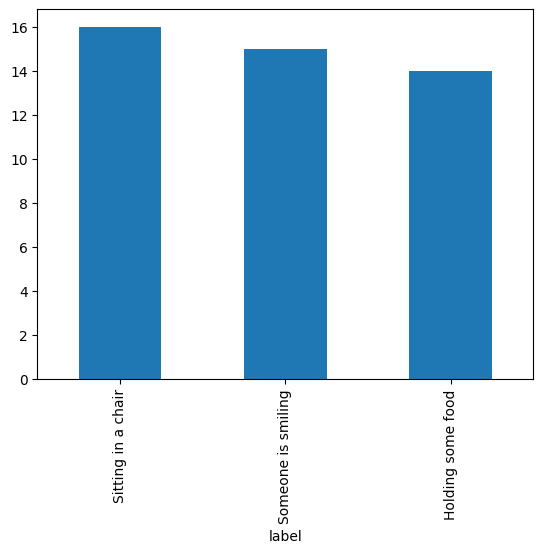

In [30]:
filtered_df['label'].value_counts().plot(kind='bar')

# Build EXO_EGO dataset

In [31]:
def build_exo_ego_dataset(
    sample_gt_df,
    category_idx_fname="../data/charades/annotations/exo_ego_category_idx3.txt",
    gt_fname="../data/charades/annotations/exo_ego_charades3.json",
):  
    # Save category index to a text file
    actions = sorted(sample_gt_df["label"].unique().tolist())
    with open(category_idx_fname, "w") as f:
        for action in actions:
            f.write(action + "\n")

    # Save sample annotations to JSON file
    output = {"version": "Charades_v1_Exo_Ego", "database": {}}

    for charades_video, group in sample_gt_df.groupby("charades_video"):
        # keep duration/subset from the original gt
        ego_id = sample_gt_df[sample_gt_df["charades_video"] == charades_video]["ego_id"].iloc[0]
        duration = sample_gt_df[sample_gt_df["charades_video"] == charades_video]["duration"].iloc[0]
        subset = sample_gt_df[sample_gt_df["charades_video"] == charades_video]["subset"].iloc[0]

        annotations = []
        for _, row in group.iterrows():
            annotations.append(
                {"segment": [row["start"], row["end"]], "label": row["label"]}
            )
        output["database"][charades_video] = {
            "ego_id": ego_id,
            "duration": duration,
            "subset": subset,
            "annotations": annotations,
        }

    with open(gt_fname, "w") as f:
        json.dump(output, f, indent=2)

In [32]:
build_exo_ego_dataset(filtered_df)